In [3]:
import torch
import matplotlib.pyplot as plt
# Prélude : la fonction logsumexp

# `Prélude : la fonction logsumexp`

 - Pour manipuler numériquement des probabilités, il est recommandé de le faire dans le domaine logarithmique, pour éviter de provoquer des underflows. 
 - Les produits de probabilité deviennent alors des sommes de log-probabilités. 
 - Il arrive dans de nombreuses situations en machine learning, où l’on tombe sur la fonction appelée ”logsumexp”, définie par :

   - Pour $\large x ∈ R^n, logsumexp(x)= log \sum_{i=0}^{n} exp(x_i)$. 

Numériquement, elle donne des valeurs proches de l’opérateur max, et est parfois appelée le ”smooth maximum”. 

Par exemple :    
  - max([1,2,3]) = 3
  - logsumexp([1,2,3]) = 3.4076

#### `Question 1. Compléter la fonction logsumexp naive`.

In [4]:
# Question 1 : Coder la fonction naive suivante
def logsumexp_naive(x):
  # Calcul naif de log sum exp du vecteur x
  logsumexp = torch.log(torch.sum(torch.exp(x)))
  # x: vecteur de réels
  return logsumexp

In [ ]:
x = torch.tensor([1.,2.,3.])
res = logsumexp_naive(x)

if torch.isclose(res, torch.tensor(3.4076)):
  print('OK !')
else:
  print('KO !')

OK !


L’exponentielle est souvent appliquée à des log probabilités, soit des valeurs trés petites.    
Que vaut logsumexp([−1000,−2000,−3000]) calculé avec la fonction logsumexp naive ?

In [6]:
x = torch.tensor([-1000.,-2000.,-3000.])
print(logsumexp_naive(x).item())

-inf


#### `Question 2 : Coder la fonction qui soustrait le max au vecteur d'entrée` 

Pour éviter les underflows, on soustrait le max du vecteur d’entrée pour stabiliser les calculs :

 - $\large logsumexp(x) = M + log \sum_{i=0}^{n} exp(x_i − M)$

Compléter la fonction logsumexp, avec cette dernière formule.

Que vaut logsumexp([−1000,−2000,−3000]) calcul´ e avec cette fonction logsumexp ?

In [7]:
# Question 2 : Coder la fonction suivante, qui soustrait le max au vecteur d'entrée
def logsumexp(x):
  # Calcul stabilisé de log sum exp du vecteur x
    # Calcul naif de log sum exp du vecteur x
  M = torch.max(x)
  logsum = M + torch.log(torch.sum(torch.exp(x - M)))
  # x: vecteur de réels
  return logsum

x = torch.tensor([-1,-0.02,-0.003])
print(logsumexp_naive(x).item())
print(logsumexp(x).item())

0.852320671081543
0.852320671081543


:::

#### `Question 3 : Coder la fonction, qui soustrait le max par % à axis`
Dans la suite, nous allons utilisons la fonction sur des matrices, où le max ne doit pas être pris sur toute la matrice, mais ligne par ligne. Il faut ajouter à la fonction précédente l’option de l’axe sur lequel on stabilise les calculs.

:::

In [8]:
# Question 3 : Coder la fonction suivante, qui soustrait le max par rapport à axis
def logsumexp(x,axis):
    maxexpct=[]
    for i in range(x.shape[0 if axis is None else 1]):
        if axis == None:
           val = x[i,:]
        else:
           val = x[:,i]
        M = torch.max(val)
        logsum = M + torch.log(torch.sum(torch.exp(val - M)))   
        maxexpct.append(logsum.item())
    return  maxexpct 

In [9]:
x = torch.tensor([[-1000.,-2000.,-3000.], [1, 2, 3]])
res = torch.tensor(logsumexp(x, None))

if torch.allclose(res, torch.tensor([-1000.0000, 3.4076]), atol=1e-04):
  print('OK !')
else:
  print('KO !')

OK !


:::

__`Problème d'apprentissage Non-supervisé`__ : 

 - Nous n'avons que des exemples de séquences d’observations. 
 - Dans ce cas, on applique un algorithme d’Estimation-Maximisation (Expectation Maximization ou EM), 
 - Expectation Maximization, remplace les fréquences par des probabilités (fréquences dites soft)

:::


:::
__`Etude de cas : deux piéces biaisées A et B`__

 - On observe des `séquences de 10 lancers` de pièces.     
 - Chaque `séquence` s'effectue `avec l'une des pièces A ou B`, sans savoir celle utilisée.     
 - On considère que la `probabilité d’utiliser A ou B est de 50%`.

A l’aide de l’algorithme EM, le problème à résoudre, est d’estimer le paramètre de la distribution de Bernoulli des pièces, à savoir :

 - $θ_A = P(Face|A)$
 - $θ_B = P(Face|B)$

:::

:::

__`Exécuter le code qui génère des données`__ : 
 - séquences de lancers de deux pièces A et B (pas de question dans cette section).
 - On génère un vecteur heads counts qui contient le nombre de faces (”heads”) obtenues sur N séquences de n lancers.

:::

:::

On utilise la `fonction torch.multinomial` pour échantillonner aléatoirement N indices selon la distribution de probabilités donnée dans le tenseur [0.5, 0.5], avec remise (chaque échantillon est indépendant des autres et peut être répété)

:::

:::

__`Explication détaillée`__ `torch.tensor([0.5, 0.5])` : c’est la distribution de probabilités sur le choix deux pièces. 

- __Représente la probabilité__ de tirer l’indice 0 ou l’indice 1 est de 50% pour chacune des pièces.​    
- __num_samples = N__ : on veut générer une liste de N tirages, donc la sortie sera de longueur N.​
- __replacement = True__ : avec remise, donc le même indice peut apparaître plusieurs fois dans le résultat.​
- __Résultat__ : un tenseur d'entiers entre 0 et 1, où chaque valeur représente un tirage selon la loi multinomiale définie par true_p.


:::

:::

`Explication`.      
 - torch.rand(n) produit un vecteur de 10 nombres aléatoires compris entre 0 et 1 
 - ce vecteur simule la probabilité associée à chacun des lancers de pièce pour la séquence considérée.
 - la valeur c indique si la pièce tirée est A pour c=0 ou B pour c=1.

__`Chaque lancé est 1 ou face si le tirage aléatoire est inférieur à la probabilité pour la pièce`__.

La sortie affiche étape par étape les séquences tirées, utile pour comprendre la simulation avant d’attaquer l’algorithme EM.

:::

In [10]:
# Cas d'étude : algorithme EM pour deux pièces biaisées A et B
torch.manual_seed(42)

# --- paramètres vrais (cachés) ---
true_p = torch.tensor([0.7, 0.4])   # probabilité de face pour les deux pièces si < prob 
true_pi = torch.tensor([0.5, 0.5])  # probabilité de tirer chaque pièce

iscoin= {0:'pièce A donne pile si p < 0.7 sinon face ',1 :'pièce B donne pile si p < 0,4 sinon face'}
# --- génération des données ---
N = 10      # nombre d'observations
n = 10      # nombre de lancers par observation

:::

On génère un vecteur heads counts qui contient le nombre de faces (”heads”) obtenues sur N séquences de n lancers.

:::

In [11]:
def generate_sequences_heads(N, n, true_p):
  # N: nb de séquences qu'on veut
  # n: nombre de lancers d'une séquence
  # true_p: vecteur avec la proba de faire face avec la pièce A et celle avec la pièce B
  sequence_pieces = torch.multinomial(torch.tensor([0.5, 0.5]), num_samples=N, replacement=True)
  sequences = torch.zeros((N, n))
  tirage = torch.zeros((N, n))
  for i,c in enumerate(sequence_pieces):
    # tirer la pièce n fois
    tirage = torch.rand(n).round(decimals=2)
    sequences[i] = tirage < true_p[int(c.item())]  
  heads_counts = torch.sum(sequences,dim=1)
  return heads_counts

## `L'algorithme EM` 

__`Log-vraisemblance`__

La vraisemblance est une fonction de $θ_A$ (respectivement $θ_B$ ), qui exprime la probabilité d’une observation ou d’un ensemble d’observations si la pièce A (resp. la pièce B) était utilisée. 

Ici, pour `une séquence de` __n__ lancers avec __k__ `faces`, cela correspond à une loi binômiale à __k__ succès pour __n__ tentatives : 

$(1) - \mathcal{L} (\theta_A) = \Bigl( \genfrac{}{}{0pt}{}{\normalsize n}{\normalsize k} \Bigl) \theta_{A}^k \left(1-\theta_A \right)^{n-k}$ 


Nous manipulons la log-vraisemblance ou log-likelihood :    

$(2) - \log \mathcal{L} (\theta_A) = \log \Bigl( \genfrac{}{}{0pt}{}{\normalsize n}{\normalsize k} \Bigl) + k \log \theta_{A} + (n - k) \log \left(1-\theta_A \right) $.   

Le coefficient binômial $\log \Bigl( \genfrac{}{}{0pt}{}{\normalsize n}{\normalsize k} \Bigl)$ est une constante vis-à-vis de $\theta$, il n’est pas utile pour trouver $\theta$     

- (_pour avoir les vraies valeurs, il faudrait l’utiliser_).  

$(3) - \log \mathcal{L} (\theta_A) = k \log \theta_{A} + (n - k) \log \left(1-\theta_A \right) $.




:::
#### `Question 4 : Compléter la fonction loglikelihood`
:::

`Que représente la valeur de vraissemblance` : 
- C’est le log de la probabilité d’observer un nombre de “face” dans une séquence, étant donné la proba de face p.
- Plus la séquence s’éloigne du comportement attendu pour p, plus la valeur est négative.

`En résumé`: 

Pour chaque séquence, on calcule la vraisemblance de la réalisation avec le modèle (p=0.7) qui est un indicateur de : 

 -  __“à quel point cet échantillon est probable, vu la vraie proba de la pièce”__

_Une valeur très négative ⇒ tirage “étonnant”._.    
_Une valeur faiblement négative ⇒ tirage conforme au modèle._

Ce calcul est fondamental en statistiques pour ajuster ou comparer des modèles à des observations réelles.

:::

La vraissemblance totale pour les deux pièces et l'ensemble des séquences de lancés avec $x_i$ faces et $i = 1...N$

$ (4) \mathcal{L} (\theta_A, \theta_B) =  \prod_{i=1}^n \frac{1}{2} P(x_i|A) + \frac{1}{2} P(x_i|B) $ 
 
$ (5) \mathcal{L} (\theta_A, \theta_B) = \frac{1}{2^n} \prod_{i=1}^n  P(x_i|A) + P(x_i|B) $

:::

:::

La log-vraisemblance associée est donnée par : 

$ (6) \log \mathcal{L} (\theta_A, \theta_B) = -N \log 2 * \sum_{i=1}^n \log (P(x_i|A) + P(x_i|B)) $

$ (7) \log \mathcal{L} (\theta_A, \theta_B) = \sum_{i=1}^n \log ( P(x_i|A) + P(x_i|B) )$
 
$ (8) $  On omet la constante $−N \log 2$. 

:::


:::

On note $l_A^i$ et $l_B^i$ les log-vraisemblances associés aux pièces A et B pour la séquence $i$.

log-vraisemblance $l_A^i =logP(x_{i}∣A)$ et $l_A^i =logP(x_{i}∣B)$

__Exprimer $\log \mathcal{L} (\theta_A, \theta_B)$ en fonction de $l_A^i$ et $l_B^i$ et introduire la fonction logsumexp.__

   -  $ l_A^i =logP(x_{i}∣A) \text{ avec } \exp(l_A^i) = P(x_{i}∣A)$ 
   -  $ l_B^i =logP(x_{i}∣B) \text{ avec } \exp(l_B^i) = P(x_{i}∣B)$ 

$ \log \mathcal{L} (\theta_A) = k \log \theta_{A} + (n - k) \log \left(1-\theta_A \right) $.

$ \log \mathcal{L} (\theta_A, \theta_B) = \sum_{i=1}^n \log ( P(x_i|A) + P(x_i|B) )$
 
:::



In [12]:
def logsumexp(x,axis):
    maxexpct=[]
    if x.dim() == 1:
        x = x.unsqueeze(0)
    for i in range(x.shape[0 if axis is not None else 1]):
        if axis == None:
           val = x[:,i]
        else:
           val = x[i,:]
        M = torch.max(val)
        logsum = M + torch.log(torch.sum(torch.exp(val - M)))   
        maxexpct.append(logsum)
    return  maxexpct 

In [13]:
def loglikelihood (count,n, true_p):  
  lkhd = torch.zeros(len(count), 2)
  lgsxp = torch.zeros(len(count))
  for i in range( len(count) ):
    for j in range( 2 ):
      lkhd[i][j] = count[i] * torch.log(true_p[j]) + (n - count[i]) * torch.log(1 - true_p[j]) 
    lgsxp[i] = logsumexp(lkhd[i],None)[0]
  return lkhd.clone().detach(), lgsxp.clone().detach()

N = 5
n = 10

torch.manual_seed(42)
true_p = torch.tensor([0.2, 0.4]) 
count = torch.tensor([9., 8., 8., 7., 4.])
lkhd, lgsmxp = loglikelihood(count, n,true_p)
if torch.allclose(lkhd[:5], torch.tensor(
      [
        [-14.7081,  -8.7574],
        [-13.3218,  -8.3520],
        [-13.3218,  -8.3520],
        [-11.9355,  -7.9465],
        [-7.7766,  -6.7301]
      ])):
  print("OK !")
else:
  print("KO !")


OK !


#### `Question 5 : compléter la fonction suivante`

In [14]:
def total_llh(llh):
  # llh: tenseur des vraisemblances, de taille N x C
  # retourne la vraisemblance totale
  return torch.sum(llh,dim=1)

total_llh(lkhd)

tensor([-23.4655, -21.6738, -21.6738, -19.8820, -14.5067])

:::

On note $l_A^i$ et $l_B^i$ les log-vraisemblances associés aux pièces A et B pour la séquence $i$.

log-vraisemblance $l_A^i =logP(x_{i}∣A)$ et $l_B^i =logP(x_{i}∣B)$

__Exprimer $\log \mathcal{L} (\theta_A, \theta_B)$ en fonction de $l_A^i$ et $l_B^i$ et introduire la fonction logsumexp.__

:::

#### `Question 6 : E-step ou Estimation step`

:::

L’étape E (estimation) produit des affectations ou des ”responsabilités” souples $r_{ik}$ qui indiquent dans quelle mesure la composante $k$ (ici la pièce A ou B) explique l’observation $i$ (le nombre de faces d’une séquence de lancers).

Ainsi, pour la pièce A (resp. B), on a :  

  $(9) $   $ \large r_{iA} = \frac {P(x_i|A)} {P(x_i|A) + P(x_i|B)}$

   -  $ log(r_{iA}) = \log \Bigl( \frac {P(x_i|A)} {P(x_i|A) + P(x_i|B)} \Bigr)$

   -  $ l_A^i =logP(x_{i}∣A) \text{ avec } \exp(l_A^i) = P(x_{i}∣A)$ 
   -  $ l_B^i =logP(x_{i}∣B) \text{ avec } \exp(l_B^i) = P(x_{i}∣B)$ 

  $(10)$   $ log(r_{iA}) =  log({P(x_i|A)}) - \log({P(x_i|A) + P(x_i|B)})$

:::

In [15]:
def Estep (count, n, true_p):
  # counts: vecteur contenant le nombre de faces sur toutes les séquences
  # n: nombre de lancers d'une séquence
  # p: vecteur des paramètres actuels
  # retourne:
  #  (a) log_lh: tenseur des log-vraisemblances de taille N x C
  #  (b) log_resp: tenseur des log-responsabilités de taille N x C

  log_resp = torch.zeros(len(count),2) 

  log_lh, lgsmxp = loglikelihood (count,n, true_p)
  lA = log_lh[:,0] #log vraisemblances individuelles
  lB = log_lh[:,1] #log vraisemblances individuelles
  
  pA = torch.exp(lA)
  pB = torch.exp(lB)

  log_resp[:,0] = lA - torch.log(pA + pB)
  log_resp[:,1] = lB - torch.log(pA + pB)
  return log_lh, log_resp

In [16]:
# test de la fonction
heads_tmp = torch.tensor([ 9.,  8.,  8.,  7.,  4.])
n_tmp = 10
p_tmp = torch.tensor([0.2, 0.8])

log_lh, log_resp = Estep(heads_tmp, n_tmp, p_tmp)
print(log_resp)

if log_resp.size() == (5, 2):
  print("Dimensions OK !")
else:
  print("Dimensions KO !")

if torch.allclose(log_resp, torch.tensor([
        [-1.1090e+01, -1.5259e-05],
        [-8.3180e+00, -2.4414e-04],
        [-8.3180e+00, -2.4414e-04],
        [-5.5491e+00, -3.8986e-03],
        [-6.0625e-02, -2.8332e+00]]), atol=1e-03):
  print("OK !")
else:
  print("KO !")


tensor([[-1.1090e+01, -1.5259e-05],
        [-8.3180e+00, -2.4414e-04],
        [-8.3180e+00, -2.4414e-04],
        [-5.5491e+00, -3.8986e-03],
        [-6.0625e-02, -2.8332e+00]])
Dimensions OK !
OK !


## `Question 7 M-step Maximisation step`

La M-step (Maximization step) est la deuxième étape de l’algorithme EM (Expectation-Maximization) utilisé pour l’estimation de paramètres dans les modèles statistiques de mélange comme les mélanges de lois (ex: mélange de deux pièces, de Gaussiennes, etc).

`En résumé` :

__E-step__ :    
$$ r_{iA} = \frac {P(x_i|A)} {P(x_i|A) + P(x_i|B)}$$
 - on calcule, pour chaque donnée, la "responsabilité" de chaque classe / modèle. 
 - quelle est la probabilité que la donnée ait été générée par chaque composant du mélange, en utilisant les paramètres actuels.

__M-step__ : 

L’étape de maximization M utilise les responsabilités rik comme poids lors de la mise à jour des paramètres recherchés ($θA$ et $θB$).         
La valeur actualisée de $θA$ (resp. $θB$ ) est donnée par :
  
 $$\theta_A =\frac{\sum_{i=1}^N r_{iA}*x_i}{\sum_{i=1}^N r_{iA}*n} = \frac{\sum_{i=1}^N r_{iA}*x_i}{n*\sum_{i=1}^N r_{iA}} $$

- on met à jour les paramètres du modèle (ici, les probabilités de chaque pièce) en maximisant la vraisemblance attendue, 
 - c’est-à-dire en utilisant les responsabilités calculées à l’E-step comme des "poids" pour chaque donnée.


### __`Compléter la fonction Mstep`__

In [17]:
# M-step
# question 7
def Mstep(counts, ngth, log_resp):
  # counts: tenseur avec les observations (nombres de faces)
  # ngth: nombre de lancers d'une séquence
  # log_resp: responsabilités dans le domaine log
  # retoune le tenseur des paramètres actualisés
  respA = log_resp[:,0].exp()
  respB = log_resp[:,1].exp()
  pA = torch.sum(respA * counts) / (ngth * torch.sum(respA))
  pB = torch.sum(respB * counts) / (ngth * torch.sum(respB))
  return torch.tensor([pA, pB])

# test de la fonction
heads_tmp = torch.tensor([ 9.,  8.,  8.,  7.,  4.])
log_resp_tmp = torch.tensor([[-1.1090e+01, -1.5259e-05],
        [-8.3180e+00, -2.4414e-04],
        [-8.3180e+00, -2.4414e-04],
        [-5.5491e+00, -3.8986e-03],
        [-6.0625e-02, -2.8332e+00]])
n_tmp = 10
p = Mstep(heads_tmp, n_tmp, log_resp_tmp)

if p.size() == (2,):
  print("Dimensions OK !")
else:
  print("Dimensions KO !")

if torch.allclose(p, torch.tensor([0.4014, 0.7943]), atol=1e-04):
  print("OK !")
else:
  print("KO !")


Dimensions OK !
OK !


### __`Question 8 Algorithme EM`__

EM est un algorithme très général, utilisé au-delà des HMM quand :

 - Des informations manquent sur les données (typiquement les labels),   
 - Les paramètres (parfois ”latents”) d’un modèle sont à estimer

__`La mise en commun des étapes Estimation et Maximisation`__.  

- Calculer la responsabilités rik à partir des paramètres actuels.     
- puis calculer les nouveaux paramètres à partir de la responsabilités rik.           
- donner l’algorithme EM général, qui est exécuté jusqu’à ce qu’un critère d’arrêt se déclenche.     
- compléter l’algorithme ci-dessous qui alterne Estep et Mstep dans une boucle for sur des itérations allant jusqu’à max iters.     
- on ajoutera un critère d’arrêt sur la variation absolue de la log-vraisemblance totale.   
- si cette variation est inférieure à *tol* (tolérance), alors la boucle s’arrête.

Compléter la fonction EM deux pieces

In [18]:
# Algorithme EM
def EM_deux_pieces(initial_params, counts, n, max_iters=100, tol=1e-6, verbose=True):

  # initialiser les params
  p = initial_params

  history = []
  prev_final_llh = -torch.inf

  for it in range(1, max_iters+1):
    log_lh, log_resp = Estep(counts, n, p)
    p = Mstep(counts, n, log_resp)
    
    # Calcul de la log-vraisemblance totale du mélange (pour convergence)
    final_llh = torch.sum(logsumexp(log_lh, None)[0])
    history.append([it, p[0].item(), p[1].item(), final_llh.item()])
    if verbose:
        print(f"it={it:3d}   p=({p[0]:.4f},{p[1]:.4f})  ll={final_llh:.4f}")
    if abs(final_llh - prev_final_llh) < tol:
            break
    prev_final_llh = final_llh
  return p, history

it=  1   p=(0.2178,0.0695)  ll=-1.3914
it=  2   p=(0.2399,0.0495)  ll=-1.5974
it=  3   p=(0.2507,0.0396)  ll=-1.8568
it=  4   p=(0.2534,0.0352)  ll=-1.9870
it=  5   p=(0.2533,0.0331)  ll=-2.0188
it=  6   p=(0.2526,0.0319)  ll=-2.0172
it=  7   p=(0.2521,0.0313)  ll=-2.0097
it=  8   p=(0.2517,0.0309)  ll=-2.0033
it=  9   p=(0.2515,0.0307)  ll=-1.9989
it= 10   p=(0.2514,0.0306)  ll=-1.9962
it= 11   p=(0.2513,0.0305)  ll=-1.9945
it= 12   p=(0.2512,0.0304)  ll=-1.9935
it= 13   p=(0.2512,0.0304)  ll=-1.9928
it= 14   p=(0.2512,0.0304)  ll=-1.9924
it= 15   p=(0.2512,0.0304)  ll=-1.9922
it= 16   p=(0.2512,0.0304)  ll=-1.9920
it= 17   p=(0.2512,0.0303)  ll=-1.9920
it= 18   p=(0.2512,0.0303)  ll=-1.9919
it= 19   p=(0.2512,0.0303)  ll=-1.9919
it= 20   p=(0.2512,0.0303)  ll=-1.9919
it= 21   p=(0.2512,0.0303)  ll=-1.9918
it= 22   p=(0.2512,0.0303)  ll=-1.9918
it= 23   p=(0.2512,0.0303)  ll=-1.9918
it= 24   p=(0.2512,0.0303)  ll=-1.9918
it= 25   p=(0.2512,0.0303)  ll=-1.9918
it= 26   p=(0.2512,0.0303

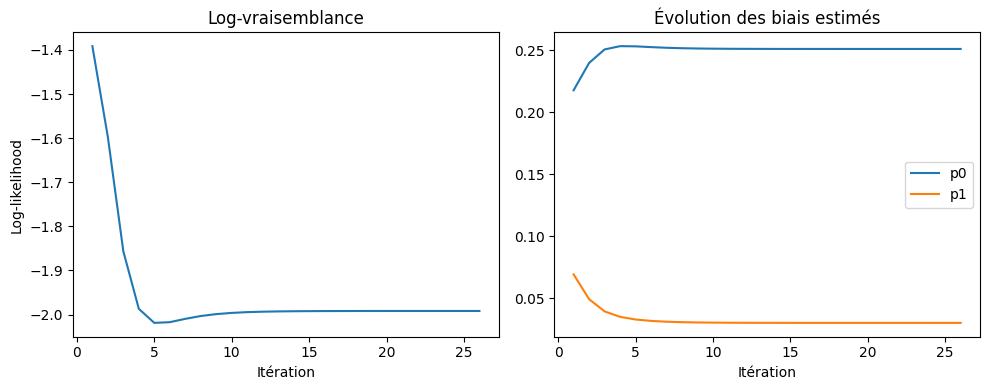

In [19]:
n =10
p = torch.tensor([0.2, 0.1])
# p = torch.tensor([0.87968681, 0.12964325])
heads_counts = generate_sequences_heads(N, n, true_p)
p_est, history = EM_deux_pieces(p, heads_counts, n, max_iters=200)

print("\nParamètres vrais (cachés):")
print(f"  p_true  = ({true_p[0]:.3f}, {true_p[1]:.3f})\n")

print("Estimations finales (ordre non garanti):")
print(f"  p_est  = ({p_est[0]:.4f}, {p_est[1]:.4f})\n")

order = torch.argsort(-p_est)
p_est_sorted = p_est[order]

print("Estimations triées par p décroissant:")
print(f"  p_sorted  = ({p_est_sorted[0]:.4f}, {p_est_sorted[1]:.4f})\n")

# tracés
it_history = [history[i][0] for i in range(len(history))]
ll_history = [history[i][3] for i in range(len(history))]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(it_history, ll_history)
plt.title('Log-vraisemblance')
plt.xlabel('Itération')
plt.ylabel('Log-likelihood')

p0_history = [history[i][1] for i in range(len(history))]
p1_history = [history[i][2] for i in range(len(history))]
plt.subplot(1,2,2)
plt.plot(it_history, p0_history, label='p0')
plt.plot(it_history, p1_history, label='p1')
plt.title('Évolution des biais estimés')
plt.xlabel('Itération')
plt.legend()

plt.tight_layout()
plt.show()

`Légende` :

 - p0 = courbe bleue (biais de la 1ère pièce)
 - p1 = courbe orange (biais de la 2ᵉ pièce)

On voit que les deux biais convergent rapidement :

 - p0 s’ajuste autour de 0.25.
 - p1 tend vers une valeur proche de 0.025 : la pièce 1 est nettement plus "déséquilibrée" ou "défavorisée" par rapport à la pièce 0 selon les séquences observées ;

La convergence est atteinte très tôt (moins de 10 itérations nécessaires).

__`Conclusion`__

EM fonctionne et converge rapidement : le modèle optimise bien les paramètres pour expliquer les données.
Les courbes montrent une optimisation efficace (hausse de log-vraisemblance, stabilisation rapide des paramètres).

Les valeurs estimées de  p0 et p1 sont plausibles et cohérentes avec un scénario où une pièce est bien plus "chanceuse" que l’autre.

Si on modifie les données, nous verrons que les valeurs finissent toujours par tendre vers les meilleures estimations possibles.

__`Question d’analyse`__

1. Quelle est l’influence du nombre de s´ equences observées sur l’estimation des paramètres ?    
2. Même question pour les valeurs initiales des paramètres.   

__Pour aller plus loin :__.   

Vous pouvez essayez d’intégrer dans les paramètres à estimer la probabilité de choisir la
pièce A (resp. la pi` ece B), car dans la version actuelle, nous avons considéré que ce choix était  équiprobable.